## Produces **Mosquito Predictions** for a specific region using MAMOTH ##

In [1]:
import pandas as pd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys

sys.path.insert(0, "../../../Mamoth Modules")
sys.path.insert(0, "../../../Modules")

from preprocessing_utils import *

from Preprocessing_Module import read_data, select_columns, reshape_dataset
from Initializer_Module import initializer
from Neural_Network_Module import Dataset, transformations, FeedforwardNeuralNetModel, train_nn, give_predictions
from Model_Validation_Module import validation_plots, metrics

enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 10

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\fuzzywuzzy\fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')
c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
NUTS0 = 'GR'
NUTS2 = 'CMacedonia'
NUTS2_EL = 'κεντρικης μακεδονιας'

In [4]:
MONTH = 'July'
PERIOD = '1st'

In [5]:
dataset = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_2023-{MONTH}-{PERIOD}_filled.csv', encoding=enc)


In [6]:
dataset.head()

,lau1,region,x,y,dt_placement,year,month,indices_image_date,indices_lat,indices_lon,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_image_date,lst_lat,lst_lon,lst_day,lst_night,monthly_lst_lat,monthly_lst_lon,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,indices_image_date.1,indices_lat.1,indices_lon.1,acc_rainfall_jan,dt_placement_minus_7,dt_placement_minus_14,dt_placement_minus_7_avail,dt_placement_minus_14_avail,acc_rainfall_1week,acc_rainfall_2week
0,αλεξανδρειας,κεντρικης μακεδονιας,22.39544,40.65816,2023-07-01,2023,7,2023-06-29,40.659996,22.397246,0.538377,0.223991,-0.459938,-0.223991,0.395259,0.076691,-0.353926,-0.076691,0.082918,0.075972,0.063432,0.075972,2023-06-28,40.659996,22.397246,15552.0,14837.0,40.659996,22.397246,14284.083333,13749.166667,14328.421053,13656.411765,14754.941176,13922.545455,15018.466667,14063.166667,2023-07-01,40.650186,22.350102,159.875884,2023-06-24,2023-06-17,2023-06-24,2023-06-17,0.030611,6.039012
1,αλεξανδρειας,κεντρικης μακεδονιας,22.46627,40.67612,2023-07-01,2023,7,2023-06-29,40.677962,22.464619,0.422487,0.083173,-0.396897,-0.083173,0.363666,0.027555,-0.349412,-0.027555,0.070431,0.055768,0.056512,0.055768,2023-06-28,40.677962,22.464619,15672.0,14827.0,40.677962,22.464619,14206.000000,13746.000000,14233.200000,13688.333333,14793.333333,13936.333333,14919.181818,14048.272727,2023-07-01,40.650186,22.450103,153.519854,2023-06-24,2023-06-17,2023-06-24,2023-06-17,0.030611,16.176531
2,αλεξανδρειας,κεντρικης μακεδονιας,22.48988,40.62222,2023-07-01,2023,7,2023-06-29,40.624063,22.491569,0.376203,0.028273,-0.372600,-0.028273,0.353207,0.018521,-0.354609,-0.018521,0.080305,0.066791,0.055745,0.066791,2023-06-28,40.624063,22.491569,15641.0,14808.0,40.624063,22.491569,14209.272727,13756.307692,14227.071429,13700.500000,14700.312500,13925.571429,14910.545455,14055.000000,2023-07-01,40.650186,22.450103,153.519854,2023-06-24,2023-06-17,2023-06-24,2023-06-17,0.030611,16.176531
3,αλεξανδρειας,κεντρικης μακεδονιας,22.58432,40.62222,2023-07-01,2023,7,2023-06-29,40.624063,22.585892,0.381307,0.025641,-0.371945,-0.025641,0.333579,-0.002407,-0.334586,0.002407,0.029418,0.025417,0.022703,0.025417,2023-06-28,40.624063,22.585892,15728.0,14752.0,40.624063,22.585892,14237.400000,13747.285714,14266.846154,13678.000000,14819.857143,13907.357143,14836.600000,14043.111111,2023-07-01,40.650186,22.550103,190.586791,2023-06-24,2023-06-17,2023-06-24,2023-06-17,0.000000,16.259712
4,αλμωπιας,κεντρικης μακεδονιας,22.06171,40.94926,2023-07-01,2023,7,2023-06-29,40.947456,22.060378,0.599495,0.188591,-0.498462,-0.188591,0.617420,0.197977,-0.512509,-0.197977,0.025113,0.028707,0.018151,0.028707,2023-06-28,40.947456,22.060378,15264.0,14664.0,40.947456,22.060378,14194.545455,13704.333333,14252.187500,13625.400000,14610.384615,13888.777778,14649.111111,14073.500000,2023-07-01,40.950187,22.050101,301.522635,2023-06-24,2023-06-17,2023-06-24,2023-06-17,9.313336,12.606888


In [7]:
dataset.rename(columns={"region": "nuts2"}, inplace=True)

In [8]:
dataset = dataset.rename(columns=lambda x: re.sub('_new', '', x))

In [9]:
dataset.drop(columns=['indices_image_date', 'indices_lat', 'indices_lon' , 'lst_image_date', 'lst_lat','lst_lon' ,'monthly_lst_lat', 'monthly_lst_lon', 
                         'indices_image_date.1', 'indices_lat.1', 'indices_lon.1', 'dt_placement_minus_7', 'dt_placement_minus_14', 'dt_placement_minus_7_avail',
                         'dt_placement_minus_14_avail'], inplace = True)

In [10]:
dataset.head(5)

,lau1,nuts2,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,αλεξανδρειας,κεντρικης μακεδονιας,22.39544,40.65816,2023-07-01,2023,7,0.538377,0.223991,-0.459938,-0.223991,0.395259,0.076691,-0.353926,-0.076691,0.082918,0.075972,0.063432,0.075972,15552.0,14837.0,14284.083333,13749.166667,14328.421053,13656.411765,14754.941176,13922.545455,15018.466667,14063.166667,159.875884,0.030611,6.039012
1,αλεξανδρειας,κεντρικης μακεδονιας,22.46627,40.67612,2023-07-01,2023,7,0.422487,0.083173,-0.396897,-0.083173,0.363666,0.027555,-0.349412,-0.027555,0.070431,0.055768,0.056512,0.055768,15672.0,14827.0,14206.000000,13746.000000,14233.200000,13688.333333,14793.333333,13936.333333,14919.181818,14048.272727,153.519854,0.030611,16.176531
2,αλεξανδρειας,κεντρικης μακεδονιας,22.48988,40.62222,2023-07-01,2023,7,0.376203,0.028273,-0.372600,-0.028273,0.353207,0.018521,-0.354609,-0.018521,0.080305,0.066791,0.055745,0.066791,15641.0,14808.0,14209.272727,13756.307692,14227.071429,13700.500000,14700.312500,13925.571429,14910.545455,14055.000000,153.519854,0.030611,16.176531
3,αλεξανδρειας,κεντρικης μακεδονιας,22.58432,40.62222,2023-07-01,2023,7,0.381307,0.025641,-0.371945,-0.025641,0.333579,-0.002407,-0.334586,0.002407,0.029418,0.025417,0.022703,0.025417,15728.0,14752.0,14237.400000,13747.285714,14266.846154,13678.000000,14819.857143,13907.357143,14836.600000,14043.111111,190.586791,0.000000,16.259712
4,αλμωπιας,κεντρικης μακεδονιας,22.06171,40.94926,2023-07-01,2023,7,0.599495,0.188591,-0.498462,-0.188591,0.617420,0.197977,-0.512509,-0.197977,0.025113,0.028707,0.018151,0.028707,15264.0,14664.0,14194.545455,13704.333333,14252.187500,13625.400000,14610.384615,13888.777778,14649.111111,14073.500000,301.522635,9.313336,12.606888


In [11]:
grouped = dataset.groupby(['dt_placement', 'lau1', 'nuts2'], as_index = False)
dataset = grouped.mean()
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,2023-07-01,αλεξανδρειας,κεντρικης μακεδονιας,22.483978,40.644680,2023.0,7.0,0.429593,0.090270,-0.400345,-0.090270,0.361428,0.030090,-0.348133,-0.030090,0.065768,0.055987,0.049598,0.055987,15648.250000,14806.000000,14234.189015,13749.690018,14263.884659,13680.811275,14767.111038,13922.951840,14921.198485,14052.387626,164.375596,0.022958,13.662946
1,2023-07-01,αλμωπιας,κεντρικης μακεδονιας,21.940791,40.977027,2023.0,7.0,0.674790,0.241809,-0.561676,-0.241809,0.692169,0.253634,-0.576864,-0.253634,0.049594,0.037586,0.038354,0.037586,14856.727273,14585.090909,14057.777305,13785.095521,14049.086598,13664.427816,14324.249349,13852.660376,14396.198124,13956.128788,328.868808,4.031316,6.652124
2,2023-07-01,αμπελοκηπων μενεμενης,κεντρικης μακεδονιας,22.891980,40.656030,2023.0,7.0,0.133415,-0.028332,-0.154901,0.028332,0.178877,-0.018693,-0.194543,0.018693,0.064165,0.025060,0.052170,0.025060,15666.000000,14856.000000,14276.571429,13837.333333,14251.000000,13783.769231,14595.538462,13913.571429,14852.400000,14251.000000,388.329452,0.152377,14.319245
3,2023-07-01,αμφιπολης,κεντρικης μακεδονιας,23.982527,40.915102,2023.0,7.0,0.609772,0.236717,-0.512593,-0.236717,0.513561,0.212443,-0.426572,-0.212443,0.070266,0.059606,0.046574,0.059606,15197.750000,14593.750000,14168.974242,13814.041667,14088.281801,13681.627828,14417.454762,13891.251136,14631.001389,13987.837500,116.063245,0.041197,1.277415
4,2023-07-01,αριστοτελη,κεντρικης μακεδονιας,23.691080,40.495934,2023.0,7.0,0.664703,0.323541,-0.558299,-0.323541,0.632944,0.316265,-0.529699,-0.316265,0.074974,0.051125,0.054211,0.051125,14935.000000,14560.375000,14191.401297,13812.444494,14125.501096,13755.012945,14425.097837,13869.602156,14508.115950,14004.449082,334.895368,0.099423,1.278498
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33,2023-07-01,σιθωνιας,κεντρικης μακεδονιας,23.828106,40.110264,2023.0,7.0,0.375316,0.109613,-0.319113,-0.109613,0.350657,0.119753,-0.284846,-0.119753,0.046339,0.060984,0.054541,0.060984,15265.200000,14670.200000,14299.930000,13928.119167,14169.179722,13820.954622,14426.578611,13938.588462,14594.725524,14073.681352,329.669878,0.242298,0.408644
34,2023-07-01,σιντικης,κεντρικης μακεδονιας,23.388058,41.313484,2023.0,7.0,0.513729,0.203068,-0.419084,-0.203068,0.531722,0.196885,-0.439452,-0.196885,0.066211,0.047130,0.055835,0.047130,15090.545455,14539.181818,14191.712236,13762.496392,14075.517520,13650.563882,14416.621580,13838.663532,14529.864895,13943.706149,172.827530,0.106766,5.056903
35,2023-07-01,σκυδρας,κεντρικης μακεδονιας,22.146700,40.822940,2023.0,7.0,0.586322,0.168004,-0.498493,-0.168004,0.577943,0.150579,-0.490954,-0.150579,0.074767,0.067703,0.052457,0.067703,15326.000000,14558.500000,14231.307692,13783.600000,14270.706478,13677.631250,14585.793956,13929.577778,14705.887500,14133.433333,210.631157,0.453822,5.394887
36,2023-07-01,χαλκηδονος,κεντρικης μακεδονιας,22.723020,40.753567,2023.0,7.0,0.294506,-0.085329,-0.316147,0.085329,0.269928,-0.097927,-0.303163,0.097927,0.034861,0.029855,0.025036,0.029855,15640.333333,14722.000000,14257.445455,13836.255556,14236.866300,13751.761905,14546.523148,13945.631235,14648.490028,14101.385185,259.263421,0.025682,19.383624


In [12]:
dataset['dt_placement'] = pd.to_datetime(dataset['dt_placement'])

In [13]:
dataset['day'] = dataset['dt_placement'].apply(lambda x : x.day)
dataset['week'] = dataset.apply(lambda row: datetime.date(int(row['year']), int(row['month']), int(row['day'])).isocalendar().week, axis=1)

In [14]:
dataset = encode_cyclical(dataset, 'day', 31)
dataset = encode_cyclical(dataset, 'month', 12)
dataset = encode_cyclical(dataset, 'week', 53)

In [15]:
mosquito_data = read_data(f'../../data/{NUTS0}_MSQ_culex_2011-2022_processed.csv')

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'sp_cnt_1km', 'biol_cnt_1km', 'wc_l_1km',
       'pg_area_1km', 'fs_area_1km', 'wc_mean_dist_1000',
       'coast_mean_dist_1000', 'dem_mean_1km', 'slope_mean_1km',
       'aspect_mean_1km', 'waw_mean_1km', 'flow_accu_1km', 'mosq_now'],
      dtype='object')


In [16]:
mosquito_data.nuts2.unique()

array(['CENTRAL MACEDONIA', 'THESSALY', 'CRETE', 'WESTERN GREECE'],
      dtype=object)

In [17]:
mosquito_data_nuts2 = mosquito_data.query("nuts2 == 'CENTRAL MACEDONIA'").copy()
mosquito_data_nuts2.reset_index(inplace = True, drop = True)

In [18]:
mosq_columns = mosquito_data_nuts2.columns
mosq_columns

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'sp_cnt_1km', 'biol_cnt_1km', 'wc_l_1km',
       'pg_area_1km', 'fs_area_1km', 'wc_mean_dist_1000',
       'coast_mean_dist_1000', 'dem_mean_1km', 'slope_mean_1km',
       'aspect_mean_1km', 'waw_mean_1km', 'flow_accu_1km', 'mosq_now'],
      dtype='object')

In [19]:
columns_to_keep = ['x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
                'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
                'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
                'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
                'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
                'acc_rainfall_jan', 'mosq_now']

mosquito_data_nuts2 = select_columns(mosquito_data_nuts2, columns_to_keep, columns_to_keep)

mosquito_data_nuts2 = reshape_dataset(mosquito_data_nuts2,['x','y','dt_placement'])

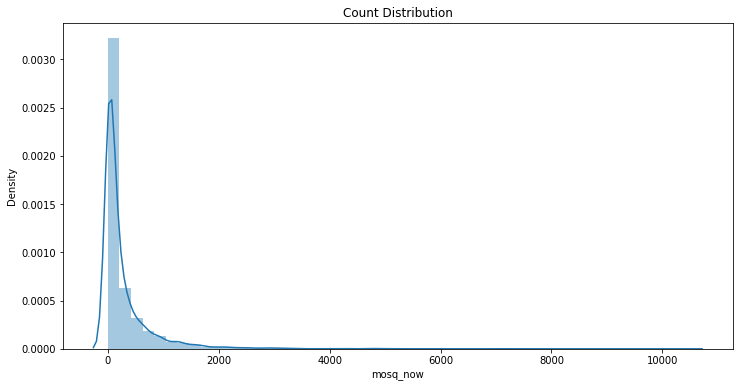

In [20]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

In [21]:
#quantile might change based on sns plots
mosq_quantilie = mosquito_data_nuts2['mosq_now'].quantile(0.90)

mosquito_data_nuts2['mosq_now'][mosquito_data_nuts2['mosq_now'] > mosq_quantilie] = mosq_quantilie+1

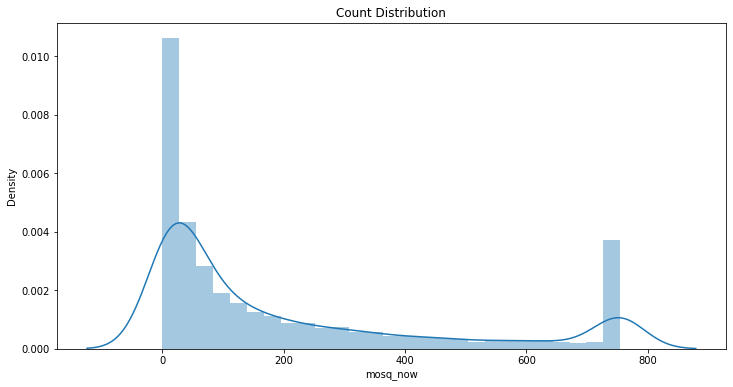

In [22]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

<AxesSubplot:>

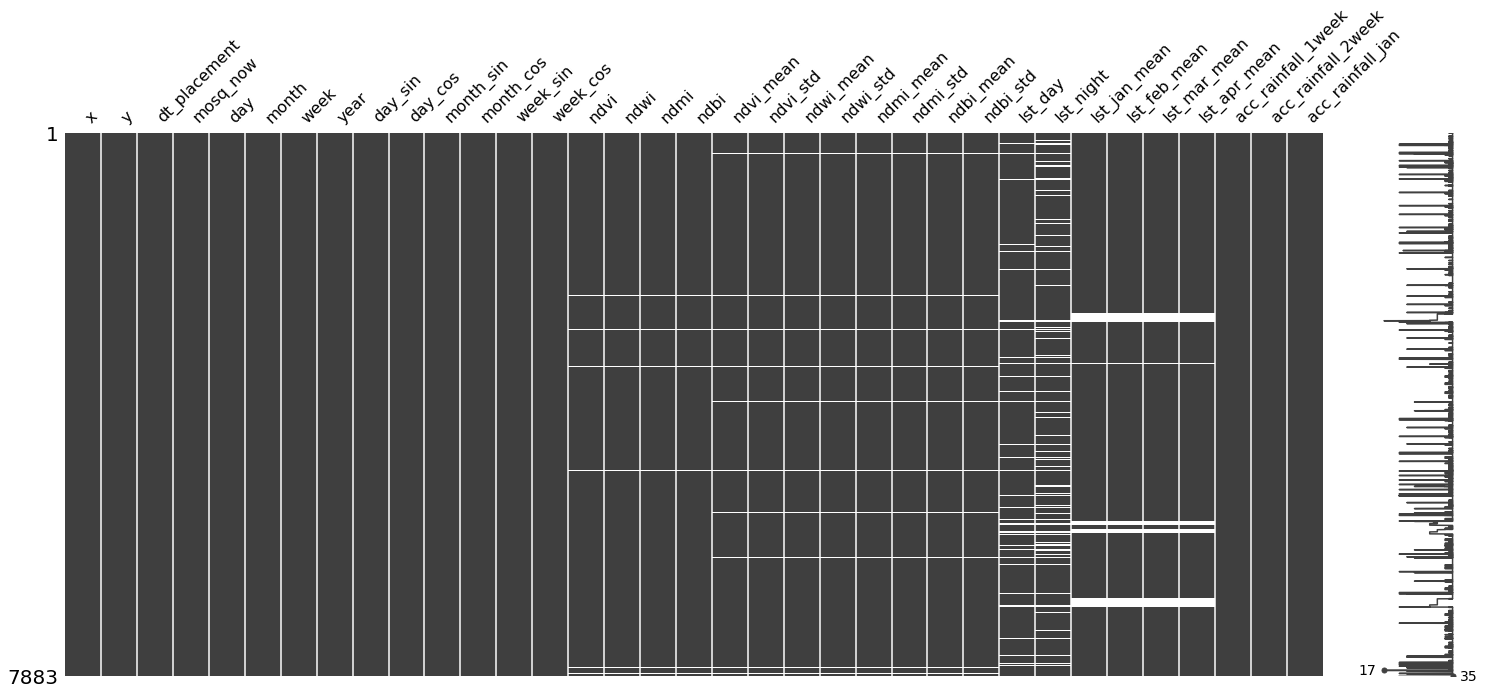

In [23]:
missingno.matrix(mosquito_data_nuts2)

In [24]:
imputer = KNNImputer()

features_for_impute = ['x', 'y', 'day', 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                        'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean', 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 
                        'lst_day', 'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan']

mosquito_data_sub = mosquito_data_nuts2[features_for_impute]

imputed_data = pd.DataFrame(imputer.fit_transform(mosquito_data_sub), columns = mosquito_data_sub.columns)

In [25]:
imputed_columns = ['ndvi','ndmi', 'ndwi', 'ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std', 'ndmi_std','ndwi_std','ndbi_std',
                   'lst_day','lst_night','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean']

mosquito_data_nuts2[imputed_columns] = imputed_data[imputed_columns]

<AxesSubplot:>

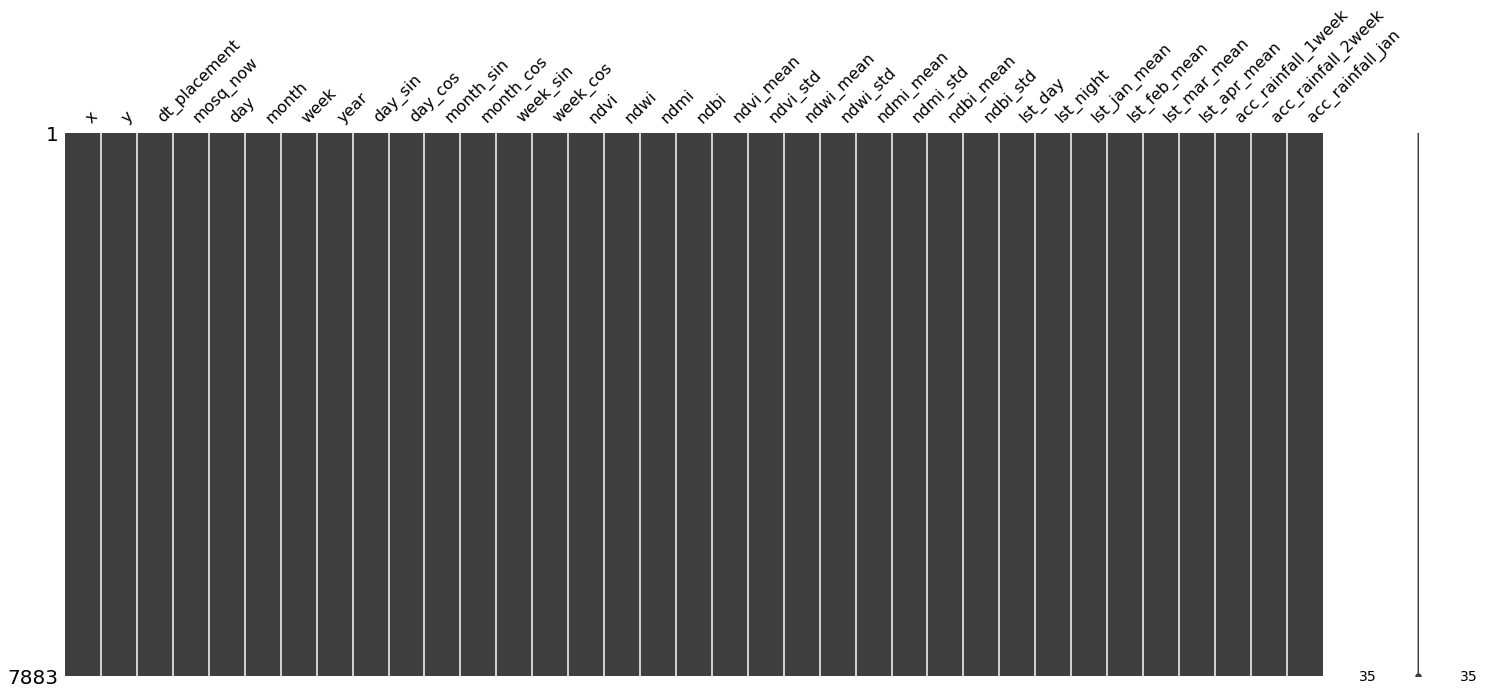

In [26]:
missingno.matrix(mosquito_data_nuts2)

In [27]:
step = 15
only_env = True
case_title = 'NN mosq regression'
exp = False
date_col = 'dt_placement'
model_type = 'mosquito_regression'
transform_target = True
augment = True

In [28]:
mosquito_data_nuts2 = initializer(mosquito_data_nuts2,2,10,25,step,[date_col], env=only_env, date_column = date_col, mosq_column='mosq_now')

Bounds: [  0.  85. 755.]


In [29]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.25, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

model = FeedforwardNeuralNetModel(num_features=len(train_X[0]), num_class=1, hidden_layers = [264,128,128,64], dropout=0.2, model_type=model_type, transform = transform_target)

Epoch 001: | Train Loss: 21.12737 | Val Loss: 24.49001 | Train Acc: 2.902| Val Acc: 2.570
Epoch 002: | Train Loss: 18.13035 | Val Loss: 26.17475 | Train Acc: 2.189| Val Acc: 2.151
Epoch 003: | Train Loss: 18.70955 | Val Loss: 24.17989 | Train Acc: 2.247| Val Acc: 2.030
Epoch 004: | Train Loss: 18.22130 | Val Loss: 23.47806 | Train Acc: 2.171| Val Acc: 2.045
Epoch 005: | Train Loss: 17.99357 | Val Loss: 23.70342 | Train Acc: 2.102| Val Acc: 2.104
Epoch 006: | Train Loss: 17.28915 | Val Loss: 24.35565 | Train Acc: 2.021| Val Acc: 1.967
Epoch 007: | Train Loss: 17.50310 | Val Loss: 23.87918 | Train Acc: 2.011| Val Acc: 1.979
Epoch 008: | Train Loss: 17.15551 | Val Loss: 23.88225 | Train Acc: 1.991| Val Acc: 1.983
Epoch 009: | Train Loss: 17.25364 | Val Loss: 23.92339 | Train Acc: 1.998| Val Acc: 2.100
Epoch 010: | Train Loss: 16.69888 | Val Loss: 23.94310 | Train Acc: 1.957| Val Acc: 1.969
Epoch 011: | Train Loss: 16.84095 | Val Loss: 23.81899 | Train Acc: 1.963| Val Acc: 2.098
Epoch 012:

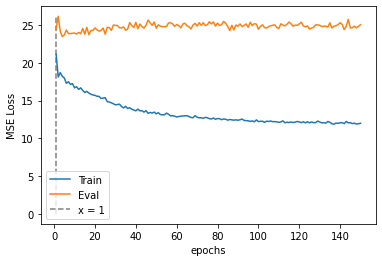

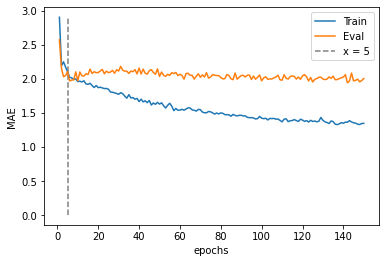

In [30]:
train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [31]:
metrics(train, test, threshold=30)

MAE on train set:  133.57288206064516
min prediction: 1
max prediction: 993

MAE on test set:  155.69147790172917
Error ⩽ 30: 18.14 %
min prediction: 1
max prediction: 977


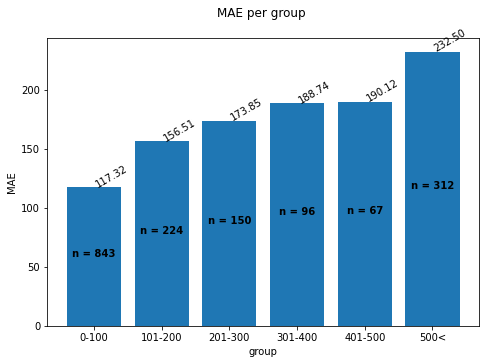

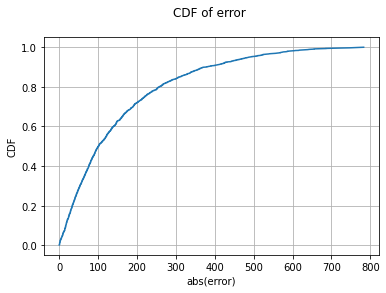

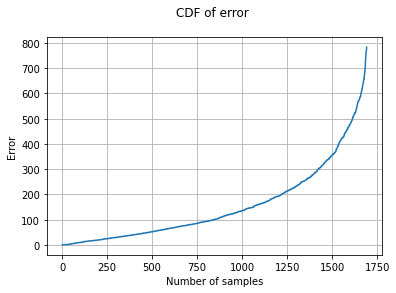

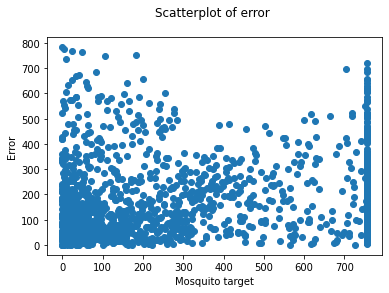

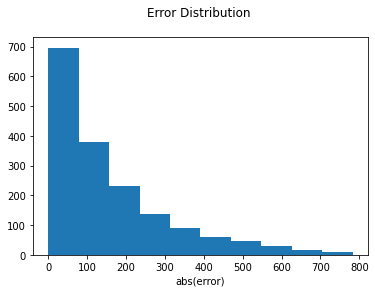

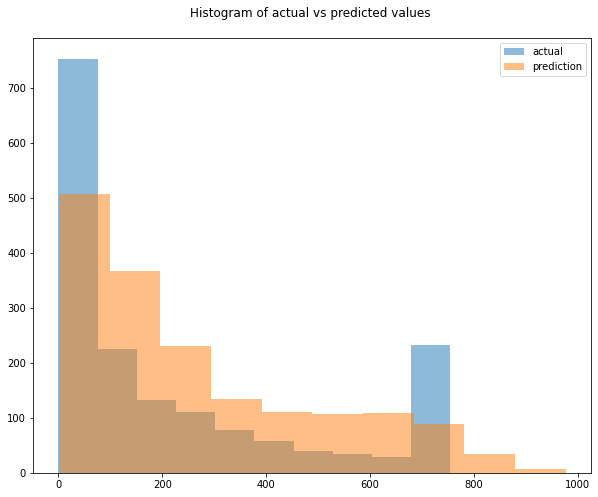

In [32]:
validation_plots(test,model_type)

Epoch 001: | Train Loss: 13.83329 | Val Loss: 3.20709 | Train Acc: 1.571| Val Acc: 1.633
Epoch 002: | Train Loss: 13.62873 | Val Loss: 3.25638 | Train Acc: 1.521| Val Acc: 1.633
Epoch 003: | Train Loss: 13.41874 | Val Loss: 4.26910 | Train Acc: 1.510| Val Acc: 1.633
Epoch 004: | Train Loss: 13.35098 | Val Loss: 3.18791 | Train Acc: 1.506| Val Acc: 1.633
Epoch 005: | Train Loss: 13.42488 | Val Loss: 6.55238 | Train Acc: 1.517| Val Acc: 2.633
Epoch 006: | Train Loss: 13.13999 | Val Loss: 5.69959 | Train Acc: 1.480| Val Acc: 2.633
Epoch 007: | Train Loss: 13.25404 | Val Loss: 6.01305 | Train Acc: 1.485| Val Acc: 2.633
Epoch 008: | Train Loss: 13.15224 | Val Loss: 5.78459 | Train Acc: 1.495| Val Acc: 2.633
Epoch 009: | Train Loss: 13.02885 | Val Loss: 8.16103 | Train Acc: 1.484| Val Acc: 2.633
Epoch 010: | Train Loss: 13.19585 | Val Loss: 6.82899 | Train Acc: 1.493| Val Acc: 2.633
Epoch 011: | Train Loss: 13.10063 | Val Loss: 3.21315 | Train Acc: 1.487| Val Acc: 1.633
Epoch 012: | Train Lo

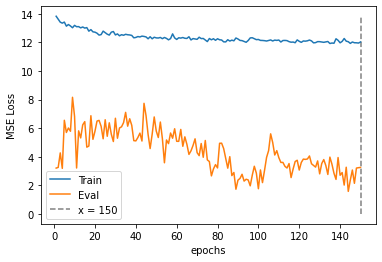

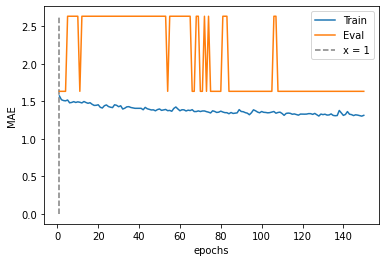

In [33]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.000001, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [34]:
dataset_mamoth = dataset_mamoth_preparation(dataset, columns_to_keep)

In [35]:
mosqutio_predictions = dataset_mamoth[['x', 'y', 'dt_placement']].copy()

In [36]:
dataset_mamoth.drop(columns=['dt_placement'], inplace=True)

In [37]:
dataset_mamoth_sub = dataset_mamoth[features_for_impute]

In [38]:
mamoth_imputed = pd.DataFrame(imputer.transform(dataset_mamoth_sub), columns = dataset_mamoth_sub.columns)

In [39]:
dataset_mamoth[features_for_impute] = mamoth_imputed[features_for_impute]

<AxesSubplot:>

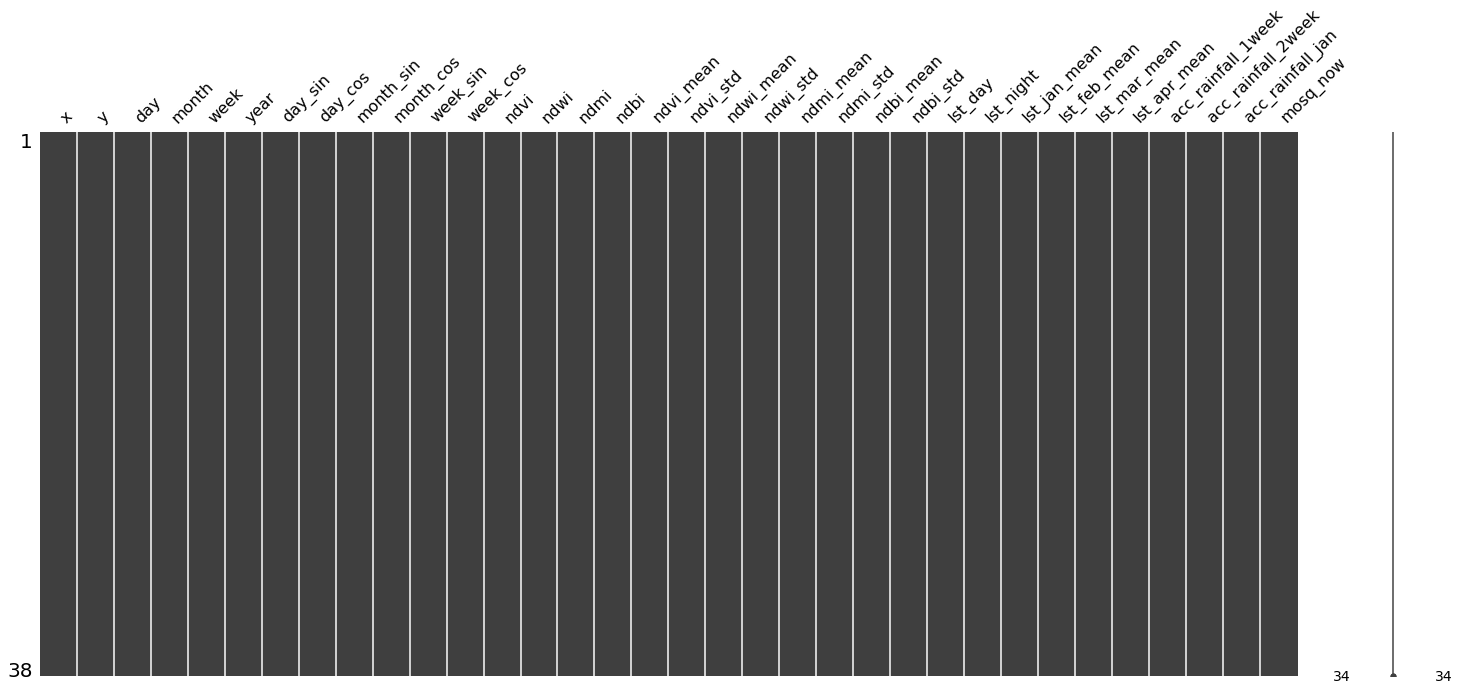

In [40]:
missingno.matrix(dataset_mamoth)

In [41]:
dataset_mamoth_X, dataset_mamoth_y = dataset_mamoth.iloc[:,:-1], dataset_mamoth.iloc[:,-1]

dataset_mamoth_X = scaler.transform(dataset_mamoth_X)

In [42]:
dataset_mamoth = Dataset(dataset_mamoth_X, dataset_mamoth_y, model_type=model_type, transform = transform_target)

In [43]:
predictions = give_predictions(model, dataset_mamoth)

In [44]:
mosqutio_predictions['mosq_pred'] = predictions

In [46]:
mosqutio_predictions

,x,y,dt_placement,mosq_pred
0,22.483978,40.644680,2023-07-01,101
1,21.940791,40.977027,2023-07-01,110
2,22.891980,40.656030,2023-07-01,107
3,23.982527,40.915102,2023-07-01,105
4,23.691080,40.495934,2023-07-01,85
...,...,...,...,...
33,23.828106,40.110264,2023-07-01,121
34,23.388058,41.313484,2023-07-01,124
35,22.146700,40.822940,2023-07-01,84
36,22.723020,40.753567,2023-07-01,129


In [47]:
mosqutio_predictions.to_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Predictions_2023-{MONTH}-{PERIOD}.csv', index = False)